Imports & Device Setup

In [14]:
pip install seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
import torch
import numpy as np
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📦 Using device: {device}")

📦 Using device: cpu


In [17]:
# GPU 상태 상세 확인
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Device Count: {torch.cuda.device_count()}")
    print(f"Current CUDA Device: {torch.cuda.current_device()}")
    print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️ CUDA is not available on this system")
    print("Possible reasons:")
    print("1. No NVIDIA GPU installed")
    print("2. GPU drivers not installed or outdated")
    print("3. PyTorch was installed without CUDA support")
    print("4. CUDA toolkit not installed")

# PyTorch 버전 확인
print(f"PyTorch Version: {torch.__version__}")

CUDA Available: False
⚠️ CUDA is not available on this system
Possible reasons:
1. No NVIDIA GPU installed
2. GPU drivers not installed or outdated
3. PyTorch was installed without CUDA support
4. CUDA toolkit not installed
PyTorch Version: 2.8.0+cpu


In [18]:
# CUDA 지원 PyTorch 설치 (CUDA 12.1 버전 권장)
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0
Found existing installation: torchvision 0.23.0
Uninstalling torchvision-0.23.0:
  Successfully uninstalled torchvision-0.23.0


You can safely remove it manually.
You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch


In [19]:
# CUDA 11.8 버전으로 PyTorch 설치 시도
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

^C


Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 62.7 MB/s eta 0:00:45
   ---------------------------------------- 0.0/2.8 GB 62.7 MB/s eta 0:00:45
    --------------------------------------- 0.0/2.8 GB 62.6 MB/s eta 0:00:45
    --------------------------------------- 0.1/2.8 GB 62.6 MB/s eta 0:00:45
    --------------------------------------- 0.1/2.8 GB 62.6 MB/s eta 0:00:44
   - -------------------------------------- 0.1/2.8 GB 62.5 MB/s eta 0:00:44
   - -------------------------------------- 0.1/2.8 GB 62.5 MB/s eta 0:00:44
   - -------------------------------------- 0.1/2.8 GB 62.5 MB/s eta 0:00:44
   - -------------------------------------- 0.1/2.8 GB 62.5 MB/s eta 0:00:44
   - -------------------------------------- 0.1/2.8 GB 62.6 MB/s eta 0:00:43
   -- ------------------------------------- 0.1/2.8 GB 62.6 MB/s eta 0:00:43
   -- -------------------

Paths & Basic Config

In [3]:
train_dir = './train'
test_dir = './test'

IMAGE_SIZE = 224
BATCH_SIZE = 32

Data Transforms

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

Datasets & Loaders

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"✅ Loaded {len(train_dataset)} training and {len(test_dataset)} test images")
print(f"📚 Number of classes: {len(class_names)} → {class_names}")

✅ Loaded 13898 training and 1546 test images
📚 Number of classes: 22 → ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


Enhanced EDA

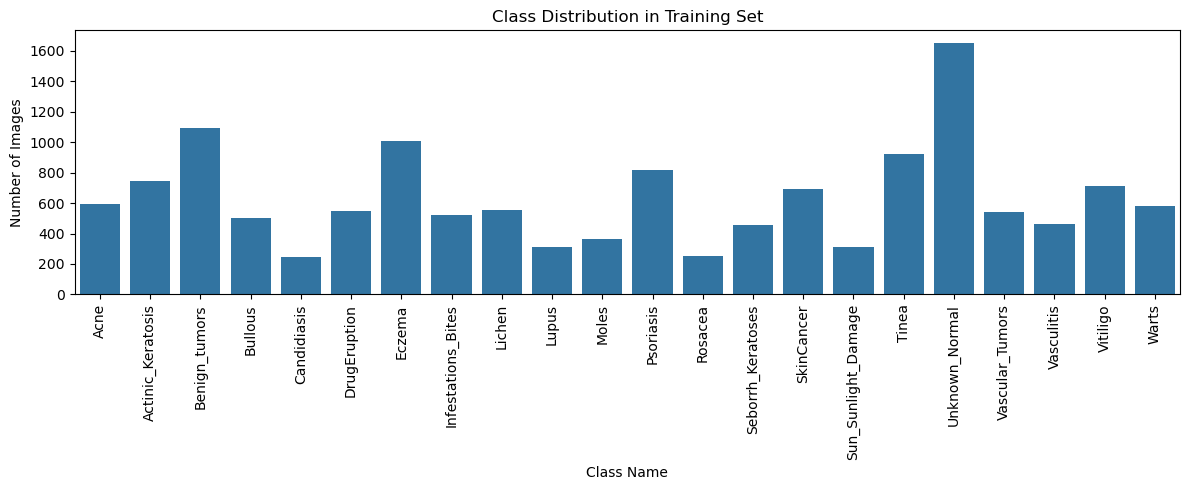

In [6]:
import seaborn as sns
from collections import Counter

# 1. Class distribution bar chart
label_counts = Counter(train_dataset.targets)
plt.figure(figsize=(12, 5))
sns.barplot(x=[class_names[i] for i in label_counts.keys()], y=list(label_counts.values()))
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.xlabel("Class Name")
plt.tight_layout()
plt.show()

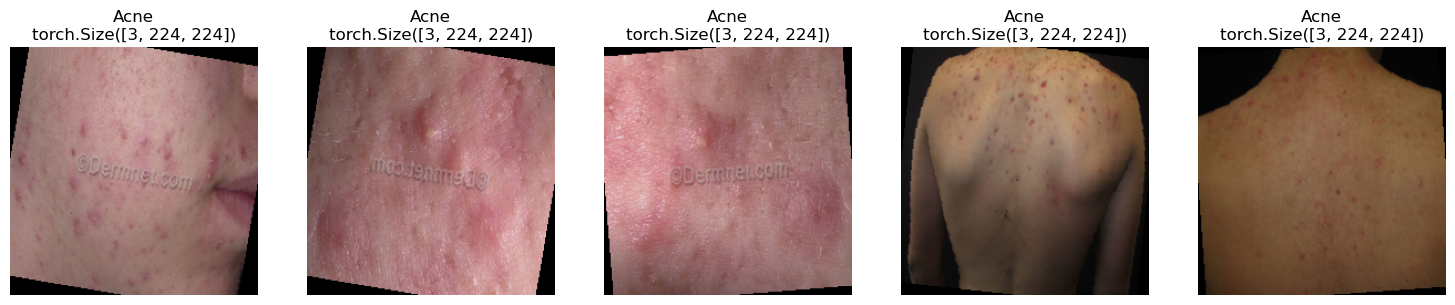

In [7]:
# 2. Visual check of sample images (with titles and shape info)
def visualize_samples(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        image, label = dataset[i]
        img_display = image.permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i].imshow(img_display)
        axes[i].set_title(f"{class_names[label]}\n{image.shape}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

visualize_samples(train_dataset)

In [8]:
# 3. Check image shape consistency
shapes = [img[0].shape for img in train_dataset]
shape_counts = Counter(shapes)
print("🖼️ Image shapes in dataset:", shape_counts)

🖼️ Image shapes in dataset: Counter({torch.Size([3, 224, 224]): 13898})


Compute Weighted Loss

In [9]:
labels = train_dataset.targets
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(labels),
                                     y=np.array(labels))
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"📊 Class weights tensor: {class_weights}")

📊 Class weights tensor: tensor([1.0653, 0.8446, 0.5780, 1.2534, 2.5473, 1.1549, 0.6255, 1.2056, 1.1424,
        2.0313, 1.7499, 0.7704, 2.4871, 1.3884, 0.9116, 2.0248, 0.6844, 0.3826,
        1.1634, 1.3703, 0.8848, 1.0892])


Resnet18 Model, Optimizer, Scheduler

In [10]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.3)
print("✅ Model ready and optimizer configured.")

✅ Model ready and optimizer configured.


c:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Split train_dataset into Train and Validation

In [11]:
from torch.utils.data import random_split, DataLoader

# Set split ratio
val_ratio = 0.1
train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

# Split dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

Full Training Code¶
Here is the full training loop with:

Class-weighted loss

Early stopping

Model checkpointing

Learning rate scheduler

Tracking and plotting learning curves

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy
import os

# Loss function with computed class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2, min_lr=1e-6)

# Training configs
EPOCHS = 20
best_val_acc = 0
patience = 4
early_stop_counter = 0
save_path = "best_skin_model.pth"

# For logging
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}  Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Early Stopping & Checkpointing
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), save_path)
        print("📌 Best model saved.")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break

# Load best model
model.load_state_dict(torch.load(save_path))
print("✅ Training complete. Best model loaded.")

Epoch 1/20  Train Loss: 2.5990, Acc: 0.2343  Val Loss: 2.4143, Acc: 0.2647
📌 Best model saved.
Epoch 2/20  Train Loss: 2.2206, Acc: 0.3346  Val Loss: 2.1125, Acc: 0.3784
📌 Best model saved.
Epoch 3/20  Train Loss: 2.0199, Acc: 0.3916  Val Loss: 2.1100, Acc: 0.3784
Epoch 4/20  Train Loss: 1.8431, Acc: 0.4362  Val Loss: 2.1228, Acc: 0.3734
Epoch 5/20  Train Loss: 1.7275, Acc: 0.4658  Val Loss: 2.0089, Acc: 0.3770
Epoch 6/20  Train Loss: 1.3511, Acc: 0.5778  Val Loss: 1.5200, Acc: 0.5345
📌 Best model saved.
Epoch 7/20  Train Loss: 1.1813, Acc: 0.6186  Val Loss: 1.5630, Acc: 0.5259
Epoch 8/20  Train Loss: 1.0703, Acc: 0.6495  Val Loss: 1.5834, Acc: 0.5317
Epoch 9/20  Train Loss: 0.9364, Acc: 0.6919  Val Loss: 1.5694, Acc: 0.5468
📌 Best model saved.
Epoch 10/20  Train Loss: 0.8136, Acc: 0.7266  Val Loss: 1.5214, Acc: 0.5914
📌 Best model saved.
Epoch 11/20  Train Loss: 0.7108, Acc: 0.7557  Val Loss: 1.4735, Acc: 0.5935
📌 Best model saved.
Epoch 12/20  Train Loss: 0.5893, Acc: 0.7924  Val Los

KeyboardInterrupt: 

Evaluate on Test Set

In [ ]:
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Put model in evaluation mode
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

Confusion Matrix

In [ ]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
labels = test_dataset.classes  # This should match your class names

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Misclassified Examples Visualization

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Collect misclassified indices
misclassified = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((images[i].cpu(), labels[i].item(), preds[i].item(), probs[i][preds[i]].item()))

# Sort by confidence (optional)
misclassified = sorted(misclassified, key=lambda x: x[3], reverse=True)

# Class names
class_names = train_dataset.classes  # already defined earlier

# Plot top 12 misclassified examples
plt.figure(figsize=(15, 10))
for idx, (img, true_label, pred_label, confidence) in enumerate(misclassified[:12]):
    plt.subplot(3, 4, idx + 1)
    img = img.permute(1, 2, 0)  # convert to HWC
    img = img * 0.5 + 0.5       # unnormalize if needed
    plt.imshow(img.numpy())
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

Misclassified Examples – Sorted by Lowest Confidence

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Store misclassified examples: (image, true_label, pred_label, confidence)
misclassified = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((
                    images[i].cpu(),
                    labels[i].item(),
                    preds[i].item(),
                    probs[i][preds[i]].item()  # model's confidence in wrong prediction
                ))

# Sort by lowest confidence
misclassified = sorted(misclassified, key=lambda x: x[3])  # ascending order

# Class names
class_names = train_dataset.classes

# Plot the 12 lowest-confidence misclassified examples
plt.figure(figsize=(15, 10))
for idx, (img, true_label, pred_label, confidence) in enumerate(misclassified[:12]):
    plt.subplot(3, 4, idx + 1)
    img = img.permute(1, 2, 0)  # CHW to HWC
    img = img * 0.5 + 0.5       # Unnormalize (if mean=0.5, std=0.5)
    plt.imshow(img.numpy())
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

Visualize Class-wise Performance with Per-Class ROC

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

model.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        y_probs.append(probs.cpu().numpy())
        y_true.extend(labels.numpy())

y_probs = np.vstack(y_probs)  # shape: (num_samples, num_classes)
y_true = np.array(y_true)


# Binarize labels
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
n_classes = y_true_bin.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(16, 12))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Per-Class ROC Curves')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

Per-Class Precision-Recall Curves

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize the true labels (y_true) into one-hot format
y_true_binarized = label_binarize(y_true, classes=range(len(class_names)))

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_binarized[:, i], y_probs[:, i])
    ap_score = average_precision_score(y_true_binarized[:, i], y_probs[:, i])
    plt.plot(recall, precision, lw=2, label=f'{class_names[i]} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Per-Class Precision-Recall Curves')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

Grad‑CAM with PyTorch

In [ ]:
import os, cv2
img_path = "./SkinDisease/test/Acne/acne-cystic-1.jpeg"
print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
print("Loaded:", img is not None)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis('off')
else:
    print("⚠️ cv2.imread failed – check file type or path")

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# Image preprocessing (same as training)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

# Load image
img_path = "./SkinDisease/test/Acne/acne-cystic-1.jpeg"
img = Image.open(img_path).convert("RGB")
input_tensor = preprocess(img).unsqueeze(0).to(device)

# Prepare hooks
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

# Register hooks
target_layer = model.layer4[-1].conv2
fwd_hook = target_layer.register_forward_hook(forward_hook)
bwd_hook = target_layer.register_backward_hook(backward_hook)

# Forward + backward
model.eval()
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
output[0, pred_class].backward()

# Get Grad-CAM
grads = gradients["value"]
acts = activations["value"]
weights = grads.mean(dim=[2, 3], keepdim=True)
cam = (weights * acts).sum(dim=1).squeeze().cpu().detach().numpy()
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam -= cam.min()
cam /= cam.max()

# Overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
img_cv = cv2.cvtColor(np.array(img.resize((224, 224))), cv2.COLOR_RGB2BGR)
overlay = cv2.addWeighted(img_cv, 0.5, heatmap, 0.5, 0)

# Show
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Grad-CAM (Pred: {class_names[pred_class]})")
plt.axis("off")
plt.show()

# Remove hooks
fwd_hook.remove()
bwd_hook.remove()

Batch Grad-CAM Visualization

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image

# Prepare preprocessing (same as training)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# Register hooks only once
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model.layer4[-1].conv2
fwd_hook = target_layer.register_forward_hook(forward_hook)
bwd_hook = target_layer.register_backward_hook(backward_hook)

# Set model to eval mode
model.eval()

# Select a batch of N images from test_loader
N = 6
batch = next(iter(test_loader))
images, labels = batch
images, labels = images[:N].to(device), labels[:N]

# Grad-CAM batch visualization
plt.figure(figsize=(12, 8))
for i in range(N):
    input_tensor = images[i].unsqueeze(0)

    # Forward and backward
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    output[0, pred_class].backward(retain_graph=True)

    # Grad-CAM
    grads = gradients["value"]
    acts = activations["value"]
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze().cpu().detach().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam -= cam.min()
    cam /= cam.max()

    # Overlay
    img = images[i].cpu().permute(1, 2, 0).numpy()
    img = ((img * 0.5) + 0.5) * 255
    img = img.astype(np.uint8)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(2, N//2, i+1)
    plt.imshow(overlay)
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[pred_class]}")
    plt.axis('off')

plt.suptitle("Grad-CAM Heatmaps for Test Samples", fontsize=14)
plt.tight_layout()
plt.show()

# Remove hooks
fwd_hook.remove()
bwd_hook.remove()

Using EfficientNet¶
✅ Benefits of Using EfficientNet

Better accuracy with fewer parameters than traditional CNNs.

Scalable: You can choose from EfficientNet-B0 to B7 depending on resource availability.

Pretrained on ImageNet, so it transfers well to medical image classification.

✅ 1. Install & Import

In [ ]:
!pip install efficientnet_pytorch

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from efficientnet_pytorch import EfficientNet
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

2. Transforms & Datasets

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = './SkinDisease/'

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

3. Compute Class Weights for Imbalance

In [ ]:
labels = [label for _, label in train_ds.samples]
class_weights = compute_class_weight('balanced', classes=range(len(train_ds.classes)), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

4. Model, Loss, Optimizer, Scheduler

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EfficientNet.from_pretrained('efficientnet-b0', num_classes=len(train_ds.classes))
model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

5. Training Loop with Early Stopping

In [ ]:
EPOCHS = 20
best_val_acc = 0
patience, counter = 5, 0
checkpoint_path = "best_efficientnet.pth"

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = train_correct = train_total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        train_correct += preds.eq(labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = val_correct = val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    print(f"Epoch {epoch}/{EPOCHS}  Train: {train_loss:.4f}, {train_acc:.4f} — Val: {val_loss:.4f}, {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print("📌 Best model saved.")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("⏹️ Early stopping.")
            break

# Load best weights
model.load_state_dict(torch.load(checkpoint_path))
print("✅ Training complete; best model loaded.")

6. Evaluation on Test Set

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_large(y_true, y_pred, class_names, figsize=(15, 12), fontsize=12):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": fontsize})
    plt.xlabel('Predicted Label', fontsize=fontsize + 2)
    plt.ylabel('True Label', fontsize=fontsize + 2)
    plt.title('Confusion Matrix', fontsize=fontsize + 4)
    plt.xticks(rotation=45, ha='right', fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_large(y_true, y_pred, class_names, figsize=(18, 15), fontsize=14)